<a href="https://colab.research.google.com/github/carlosprr29/ai-progetto-spagnoli/blob/main/notebooks/03_3_BERT_Training_Maestro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =================================================================
# MASTER MODEL TRAINING (FUSION)
# =================================================================
import os
import sys
from google.colab import drive

In [ ]:
# 1. MOUNT DRIVE AND SETUP PATHS
# -----------------------------------------------------------------
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/Project_IA'
sys.path.append(PROJECT_PATH)

In [ ]:
# ============================================
# 🔹 2. PROJECT IMPORTS
# ============================================
from src.data_loader import create_fusion_dataset
from src.bert_utils import clean_master_fusion, train_bert_expert
from src.eda_utils import plot_ablation_results

# General libraries
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
# ============================================
# 🔹 3. LOAD DATASET
# ============================================
# Execute full pipeline: load + clean + merge

df = create_fusion_dataset(PROJECT_PATH)

print("Dataset loaded successfully")
display(df.head())

In [ ]:
# ============================================
# 🔹 4. OPTIONAL TEXT CLEANING
# ============================================
# Apply additional cleaning to prevent data leakage
df['title_clean'] = df['title'].apply(clean_master_fusion)
df['text_clean'] = df['text'].apply(clean_master_fusion)
df['total_clean'] = df['title_clean'] + " [SEP] " + df['text_clean']

In [ ]:
# 5. STRATIFIED SAMPLING (Fair Comparison Strategy)
# -----------------------------------------------------------------
# We use a 15,000 sample for both tests to ensure the Ablation Study
# compares quality of data, not quantity of data.
df_sample = df.sample(n=15000, random_state=42, weights=None)

train_df, test_df = train_test_split(
    df_sample, test_size=0.2, random_state=42, stratify=df_sample["label"]
)

print("Data split:")
print(f"Train: {len(train_df)} | Test: {len(test_df)}")

In [ ]:
# 6. EXECUTION OF THE ABLATION STUDY
# -----------------------------------------------------------------
# Task A: Titles Only
trainer_tit, model_tit, token_tit = train_bert_expert(
    train_df["title_clean"], test_df["title_clean"],
    train_df["label"], test_df["label"], "TITLES_ONLY", max_len=128
)



# Task B: Full Content (The "Real" Test)
trainer_full, model_full, token_full = train_bert_expert(
    train_df["total_clean"], test_df["total_clean"],
    train_df["label"], test_df["label"], "FULL_CONTENT", max_len=256
)

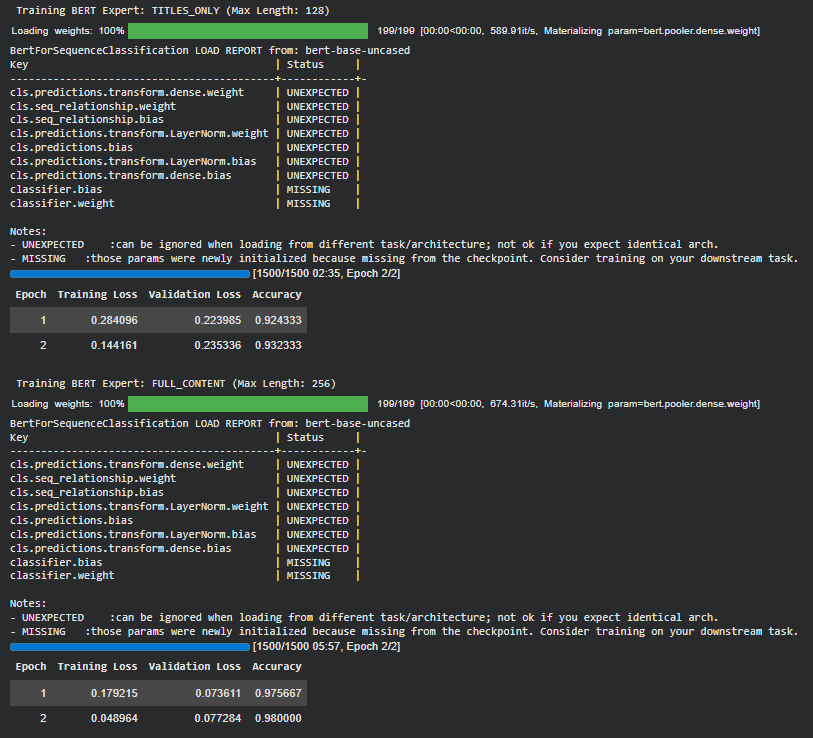

In [ ]:
# 7. PERSISTENCE AND GOOGLE DRIVE EXPORT
# -----------------------------------------------------------------
print("Saving ISOT models and exporting to Drive...")

# 1. Save the Titles-Only Expert (Weights & Tokenizer)
model_tit.save_pretrained('./model_fusion_titles')
token_tit.save_pretrained('./model_fusion_titles')
# 2. Save the Full-Content Expert (Weights & Tokenizer)
model_full.save_pretrained('./model_fusion_full')
token_full.save_pretrained('./model_fusion_full')

import shutil
# Define target paths
drive_path = '/content/drive/MyDrive/Project_IA/'
# Create project folder if it doesn't exist
if not os.path.exists(drive_path):
    os.makedirs(drive_path)

# Copy directories to Drive (using dirs_exist_ok to allow overwriting during re-runs)
shutil.copytree('./model_fusion_titles', drive_path + 'model_fusion_titles', dirs_exist_ok=True)
shutil.copytree('./model_fusion_full', drive_path + 'model_fusion_full', dirs_exist_ok=True)

print(" ISOT Models successfully exported.")

In [ ]:
# 8. FINAL VISUALIZATION (RE-FIXED)
# -----------------------------------------------------------------
plot_ablation_results(trainer_tit, trainer_full)

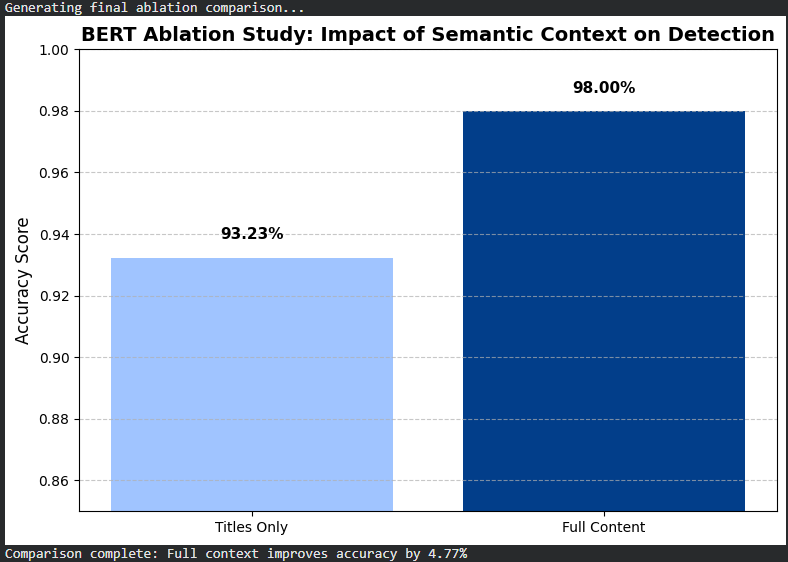

#Conclusion

While the Fusion model achieved a high accuracy of 98.13%, these results should be interpreted with caution. Despite our advanced "Master Cleaning" and the merging of datasets, the near-perfect scores suggest that residual linguistic biases and stylistic shortcuts may still exist within the data.

However, our ablation study clearly demonstrates that BERT is significantly more efficient when processing the full text rather than the title alone. By providing the complete semantic context, the model can identify deeper patterns of disinformation, confirming that the relationship between headlines and body text is essential for robust fake news detection.